# Data Quality Audit of Raw Data from the Joint Allocation Office (JAO)

The main objective of the data quality audit is to assess the quality, consistency, and general characteristics of the raw data obtained from theJoint Allocation Office (JAO).

The analysis focuses on the following aspects:
* Missing data and missing observations
* Index integrity and consistency
* Duplicated indices
* Timestamp and time zone consistency
* Value ranges and descriptive statistics for each data type
* Overall data characteristics

**All data and variables fetched from JAO are explained in the [JAO data overview](./01_JAO_data_overview.ipynb).**

In [1]:
import sys
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd().parent.parent))
from src.config import (
    DATA_DIR,
    DOWNLOAD_START_DATE,
    DOWNLOAD_END_DATE,
)
from src.eda.validation import (
    print_index_summary,
    print_missing_values,
    find_missing_dates,
)

In [2]:
data_dir = DATA_DIR / "raw" / "jao" / f"{DOWNLOAD_START_DATE}_{DOWNLOAD_END_DATE}"
data_jao = {}
for file in data_dir.iterdir():
    data = pd.read_parquet(file)
    key = file.stem
    data_jao[key] = data

## 1. Missing Data

In [3]:
for name, data in data_jao.items():
    print_missing_values(data=data, name=name)


--- [ refprog ] Missing data ---
border_DK1_UK_Viking1      30527
border_DK1_UK_Viking2      30527
border_IT_MEMONITA2         9528
border_ME_ITMONITA2         9528
border_RO_MD               27696
border_RS_KS                2016
border_UA_MD               27696
border_ES_MA_ESMA_link1    10368
border_ES_MA_ESMA_link2    10368
border_KS_ME               10368
border_SI_HU               10368
border_KS_AL               10368
border_MK_KS               10368
border_DE_DE_DK1_VH        30839
border_DE_DK2_BigHub_DE    30839
border_NL_DK1_COBRA        30839
border_RO_RO_BG_VH         30839
border_NL_NL_NO2_NorNed    30839
border_DE_NO2_BigHub_DE    30839
border_DE_DE_SE4_Baltic    30839
border_PL_PL_SE4_SwePol    30839
border_PL_LT_BigHub_PL     30839

--- [ minmax_np ] Missing data ---
minDE_NO2_BigHub    30911
minNL_NO2_NorNed    30911
minDE_DK2_BigHub    30911
minDE_SE4_Baltic    30911
minPL_LT_BigHub     30911
minPL_SE4_SwePol    30911
minRO_BG_VH         30911
minNL_DK1_COBRA     30

## 2. Missing Data - observations

The datasets for **Core CCR (Core Capacity Calculation Region) countries and bidding zones** do not contain missing values.

Some borders included in the dataset are **non-Core connections** or connect Core and non-Core bidding zones. As a result, different data publication rules apply to these connections. This is particularly relevant for the Polish interconnectors with **Lithuania (PL-LT)** and **Sweden (PL-SE4)**.

For these two borders, **RefProg** data is available only from **June 2026**. This is related to the introduction of the **Core Advanced Hybrid Coupling (AHC)** process on **11 June 2026**, which changed the treatment of these interconnectors within the capacity calculation and data publication framework.

## 3. Index Integrity

In [4]:
for name, data in data_jao.items():
    print_index_summary(data=data, name=name)


--- [ refprog ] Index integrity ---
Duplicates: 0
Timezone:  Europe/Amsterdam

Time steps:
  0 days 01:00:00: 33163
  1 days 01:00:00: 3

--- [ minmax_np ] Index integrity ---
Duplicates: 0
Timezone:  Europe/Amsterdam

Time steps:
  0 days 01:00:00: 33262

--- [ d2cf ] Index integrity ---
Duplicates: 0
Timezone:  Europe/Amsterdam

Time steps:
  0 days 01:00:00: 33155
  0 days 02:00:00: 4
  1 days 01:00:00: 3

--- [ allocation_constraint ] Index integrity ---
Duplicates: 0
Timezone:  Europe/Amsterdam

Time steps:
  0 days 00:15:00: 33599
  0 days 01:00:00: 24789
  1 days 01:00:00: 2


In [5]:
for name, data in data_jao.items():
    find_missing_dates(data=data, name=name)

number of missing indices in [refprog]: 3
missing ranges:
  2023-10-30 00:00:00+01:00
  2024-06-25 00:00:00+02:00
  2024-10-28 00:00:00+01:00
missing indices by day of week:
  Monday: 2
  Tuesday: 1
number of missing indices in [minmax_np]: 0
number of missing indices in [d2cf]: 3
missing ranges:
  2023-10-30 00:00:00+01:00
  2024-06-25 00:00:00+02:00
  2024-10-28 00:00:00+01:00
missing indices by day of week:
  Monday: 2
  Tuesday: 1
number of missing indices in [allocation_constraint]: 2
missing ranges:
  2023-10-30 00:00:00+01:00
  2024-10-28 00:00:00+01:00
missing indices by day of week:
  Monday: 2


## 3. Index Integrity - observations

No significant **index integrity issues** were identified across the datasets. The observed gaps are generally limited to **2–3 MTUs** and do not indicate broader irregularities in the time index structure.

## 4. Visual Analysis for selected data

In [6]:
sns.set_style()

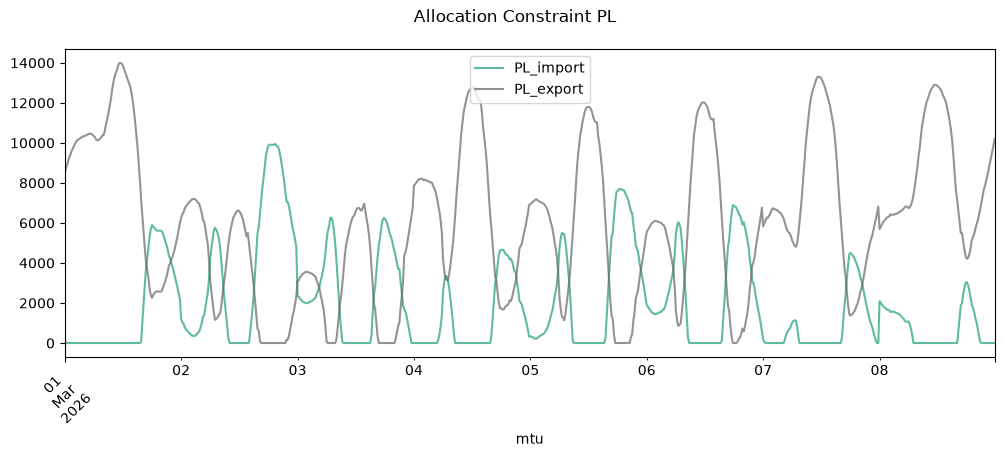

In [7]:
allocation_constraint = data_jao["allocation_constraint"]
allocation_constraint_pl = allocation_constraint[
    [c for c in allocation_constraint.columns if "PL" in c]
]
allocation_constraint_pl.loc["2026-03-01":"2026-03-08"].plot(
    figsize=(12, 4), alpha=0.7, cmap="Dark2"
)
plt.suptitle("Allocation Constraint PL")
plt.xticks(rotation=45)
plt.show()

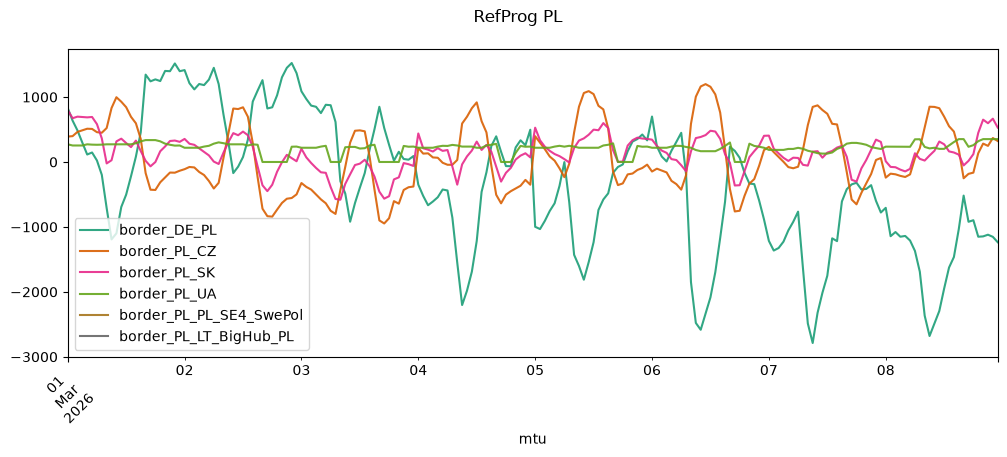

In [8]:
refprog = data_jao["refprog"]
refprog_pl = refprog[[c for c in refprog.columns if "PL" in c]]
refprog_pl.loc["2026-03-01":"2026-03-08"].plot(figsize=(12, 4), alpha=0.9, cmap="Dark2")
plt.suptitle("RefProg PL")
plt.xticks(rotation=45)
plt.show()

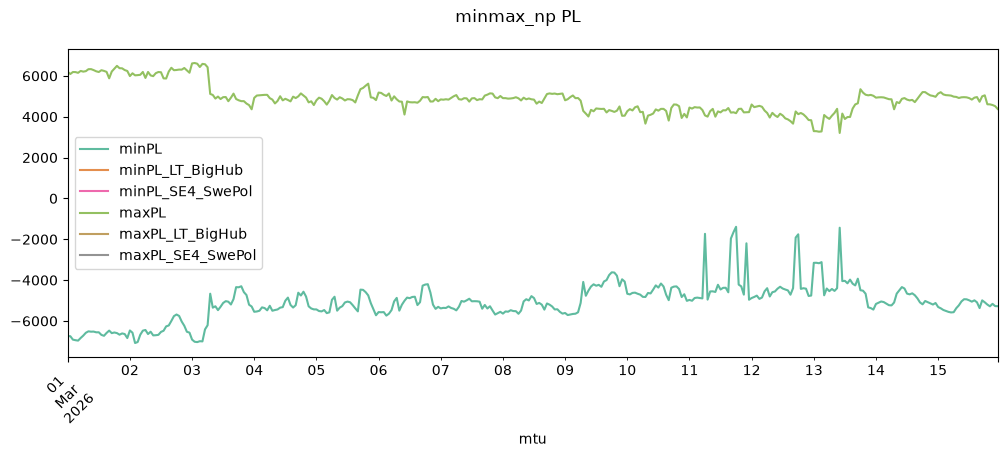

In [9]:
minmax_np = data_jao["minmax_np"]
minmax_np_pl = minmax_np[[c for c in minmax_np.columns if "PL" in c]]
minmax_np_pl.loc["2026-03-01":"2026-03-15"].plot(
    figsize=(12, 4), alpha=0.7, cmap="Dark2"
)
plt.suptitle("minmax_np PL")
plt.xticks(rotation=45)
plt.show()

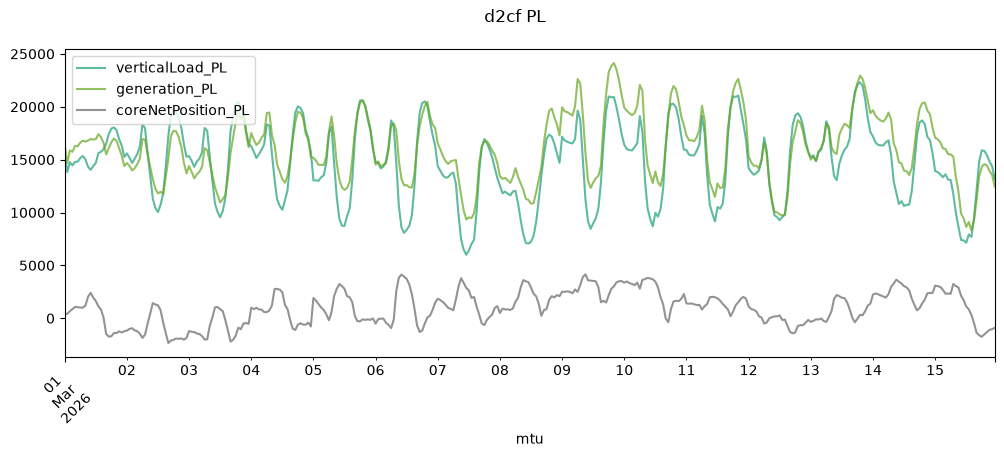

In [10]:
d2cf = data_jao["d2cf"]
d2cf_pl = d2cf[[c for c in d2cf.columns if "PL" in c]]
d2cf_pl.loc["2026-03-01":"2026-03-15"].plot(figsize=(12, 4), alpha=0.7, cmap="Dark2")
plt.suptitle("d2cf PL")
plt.xticks(rotation=45)
plt.show()

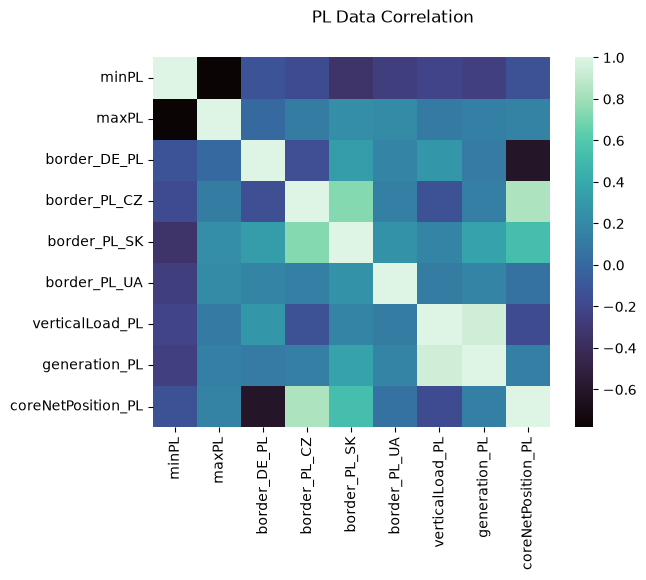

In [11]:
data_pl = pd.concat([minmax_np_pl, refprog_pl, d2cf_pl], axis=1)
sns.heatmap(
    data_pl[[c for c in data_pl.columns if "LT" not in c and "SE4" not in c]].corr(),
    cmap="mako",
)
plt.suptitle("PL Data Correlation")
plt.show()

## 5. Conclusions and data preprocessing decisions

**5.1** The datasets related to **Core CCR countries and bidding zones** contain no missing values. Therefore, **no imputation methods will be required** for these datasets.

**5.2** No significant **index integrity issues** were identified. The observed gaps, which are generally limited to **2–3 MTUs**, will be filled using **linear interpolation** to ensure continuous time series for further analysis.

**5.3** Data for the **non-Core connections involving Poland**, specifically **PL-LT** and **PL-SE4**, will not be used in further analysis. The relatively short period of data availability results in a substantial amount of missing data, making reliable imputation inappropriate.